In [1]:
import os

import ast
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["WANDB_API_KEY"] = (
    ""
)

In [2]:
import pandas as pd
import wandb

api = wandb.Api()

# Project is specified by <entity/project-name>
runs = api.runs("julian_oelhaf/fc-fl-comparison")

summary_list, config_list, name_list = [], [], []
for run in runs:
    # .summary contains the output keys/values for metrics like accuracy.
    #  We call ._json_dict to omit large files
    summary_list.append(run.summary._json_dict)

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})

    # .name is the human-readable name of the run.
    name_list.append(run.name)

runs_df = pd.DataFrame(
    {"summary": summary_list, "config": config_list, "name": name_list}
)

wandb: Currently logged in as: julian-oelhaf (julian_oelhaf) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
from ast import literal_eval
from typing import Any


feature_names = [
    "Bus_1_Line_01_02A_cur_L1_A",
    "Bus_1_Line_01_02A_cur_L2_A",
    "Bus_1_Line_01_02A_cur_L3_A",
    "Bus_1_Line_01_02A_vol_L1_V",
    "Bus_1_Line_01_02A_vol_L2_V",
    "Bus_1_Line_01_02A_vol_L3_V",
    "Bus_1_Line_01_02B_cur_L1_A",
    "Bus_1_Line_01_02B_cur_L2_A",
    "Bus_1_Line_01_02B_cur_L3_A",
    "Bus_1_Line_01_02B_vol_L1_V",
    "Bus_1_Line_01_02B_vol_L2_V",
    "Bus_1_Line_01_02B_vol_L3_V",
    "Bus_2_Line_01_02A_cur_L1_A",
    "Bus_2_Line_01_02A_cur_L2_A",
    "Bus_2_Line_01_02A_cur_L3_A",
    "Bus_2_Line_01_02A_vol_L1_V",
    "Bus_2_Line_01_02A_vol_L2_V",
    "Bus_2_Line_01_02A_vol_L3_V",
    "Bus_2_Line_01_02B_cur_L1_A",
    "Bus_2_Line_01_02B_cur_L2_A",
    "Bus_2_Line_01_02B_cur_L3_A",
    "Bus_2_Line_01_02B_vol_L1_V",
    "Bus_2_Line_01_02B_vol_L2_V",
    "Bus_2_Line_01_02B_vol_L3_V",
    "Bus_2_Line_02_03A_cur_L1_A",
    "Bus_2_Line_02_03A_cur_L2_A",
    "Bus_2_Line_02_03A_cur_L3_A",
    "Bus_2_Line_02_03A_vol_L1_V",
    "Bus_2_Line_02_03A_vol_L2_V",
    "Bus_2_Line_02_03A_vol_L3_V",
    "Bus_2_Line_02_03B_cur_L1_A",
    "Bus_2_Line_02_03B_cur_L2_A",
    "Bus_2_Line_02_03B_cur_L3_A",
    "Bus_2_Line_02_03B_vol_L1_V",
    "Bus_2_Line_02_03B_vol_L2_V",
    "Bus_2_Line_02_03B_vol_L3_V",
    "Bus_3_Line_02_03A_cur_L1_A",
    "Bus_3_Line_02_03A_cur_L2_A",
    "Bus_3_Line_02_03A_cur_L3_A",
    "Bus_3_Line_02_03A_vol_L1_V",
    "Bus_3_Line_02_03A_vol_L2_V",
    "Bus_3_Line_02_03A_vol_L3_V",
    "Bus_3_Line_02_03B_cur_L1_A",
    "Bus_3_Line_02_03B_cur_L2_A",
    "Bus_3_Line_02_03B_cur_L3_A",
    "Bus_3_Line_02_03B_vol_L1_V",
    "Bus_3_Line_02_03B_vol_L2_V",
    "Bus_3_Line_02_03B_vol_L3_V",
]


def relay_prefix_from_feature_name(feature_name: str) -> str:
    # remove the last 3 tokens: cur/vol, L1/L2/L3, A/V
    return "_".join(feature_name.split("_")[:-3])


def build_relay_dicts(feature_names: list[str], features_per_relay: int = 6):
    if len(feature_names) % features_per_relay != 0:
        raise ValueError(
            f"len(feature_names)={len(feature_names)} is not divisible by "
            f"features_per_relay={features_per_relay}"
        )

    n_relays = len(feature_names) // features_per_relay

    relay_idx_to_name = {}
    relay_idx_to_features = {}
    relay_idx_to_bus_line = {}

    for relay_idx in range(n_relays):
        start = relay_idx * features_per_relay
        end = start + features_per_relay
        relay_features = feature_names[start:end]

        relay_name = relay_prefix_from_feature_name(relay_features[0])

        # sanity check: all 6 features should belong to same relay block
        unique_prefixes = {relay_prefix_from_feature_name(f) for f in relay_features}
        if len(unique_prefixes) != 1:
            raise ValueError(
                f"Relay block {relay_idx} is inconsistent: {unique_prefixes}"
            )

        relay_idx_to_name[relay_idx] = relay_name
        relay_idx_to_features[relay_idx] = relay_features

        # optional: more compact metadata
        parts = relay_name.split("_")
        relay_idx_to_bus_line[relay_idx] = {
            "bus": f"{parts[0]}_{parts[1]}",  # e.g. Bus_1
            "line": f"{parts[2]}_{parts[3]}_{parts[4]}",  # e.g. Line_01_02A
            "relay_name": relay_name,
        }

    return relay_idx_to_name, relay_idx_to_features, relay_idx_to_bus_line


def normalize_subset_key(x: Any) -> tuple[int, ...]:
    if isinstance(x, tuple):
        return tuple(int(v) for v in x)
    if isinstance(x, list):
        return tuple(int(v) for v in x)
    if isinstance(x, str):
        x = x.strip()
        parsed = literal_eval(x)
        if isinstance(parsed, (list, tuple)):
            return tuple(int(v) for v in parsed)
    raise ValueError(f"Cannot parse subset key: {x}")


def build_subset_name_map(
    relay_idx_to_name: dict[int, str],
    subset_keys: list[Any] | None = None,
) -> dict[tuple[int, ...], str]:
    """
    Creates labels like:
      (0, 2) -> "Line_01_02_A"
    """
    if subset_keys is None:
        subset_keys = []

    out = {}
    for key in subset_keys:
        key_t = normalize_subset_key(key)
        joint_key = " + ".join(relay_idx_to_name[idx] for idx in key_t)
        # 'Bus_1_Line_01_02A + Bus_2_Line_01_02A' -> 'Line_01_02A'
        # check that all relays in the subset belong to the same line
        line_names = {
            relay_idx_to_name[idx].split("_", 3)[-1] for idx in key_t
        }  # get the line part of the relay name
        if len(line_names) == 1:
            line_name = line_names.pop()
            out[key_t] = "Line_" + line_name
        else:
            out[key_t] = joint_key  # fallback to the full joint key if not same line

    return out

In [4]:
relay_idx_to_name, relay_idx_to_features, relay_idx_to_bus_line = build_relay_dicts(
    feature_names=feature_names,
    features_per_relay=6,
)

relay_idx_to_name

{0: 'Bus_1_Line_01_02A',
 1: 'Bus_1_Line_01_02B',
 2: 'Bus_2_Line_01_02A',
 3: 'Bus_2_Line_01_02B',
 4: 'Bus_2_Line_02_03A',
 5: 'Bus_2_Line_02_03B',
 6: 'Bus_3_Line_02_03A',
 7: 'Bus_3_Line_02_03B'}

In [5]:
subset_keys = [(0, 2), (4, 6), (1, 3), (5, 7)]
relay_subset_name_map = build_subset_name_map(relay_idx_to_name, subset_keys)
relay_subset_name_map

{(0, 2): 'Line_01_02A',
 (4, 6): 'Line_02_03A',
 (1, 3): 'Line_01_02B',
 (5, 7): 'Line_02_03B'}

In [6]:
def flatten_runs_df(runs_df: pd.DataFrame) -> pd.DataFrame:
    """
    Flatten the nested `config` and `summary` dict columns of a W&B runs dataframe.
    Assumes runs_df has at least: ['config', 'summary', 'name'].
    """
    config_df = pd.json_normalize(runs_df["config"], sep="/")
    summary_df = pd.json_normalize(runs_df["summary"], sep="/")

    flat_df = pd.concat(
        [
            runs_df[["name"]].reset_index(drop=True),
            config_df.reset_index(drop=True),
            summary_df.reset_index(drop=True),
        ],
        axis=1,
    )
    return flat_df

In [7]:
flat_df = flatten_runs_df(runs_df)
flat_df.shape

(511, 310)

In [41]:
flat_df[flat_df["ablation/enabled"] == True]

,name,task/type,model/name,cv/n_splits,hgb/max_iter,features/flat,hgb/max_depth,window/step_s,cv/random_state,window/length_s,...,cv/oof/fault_only_fault_start/f1_by_fault_line/size,cv/oof/fault_start_only/f1_by_fault_line/_latest_artifact_path,cv/oof/fault_start_only/f1_by_fault_line/_type,cv/oof/fault_start_only/f1_by_fault_line/artifact_path,cv/oof/fault_start_only/f1_by_fault_line/log_mode,cv/oof/fault_start_only/f1_by_fault_line/ncols,cv/oof/fault_start_only/f1_by_fault_line/nrows,cv/oof/fault_start_only/f1_by_fault_line/path,cv/oof/fault_start_only/f1_by_fault_line/sha256,cv/oof/fault_start_only/f1_by_fault_line/size
403,sweet-forest-666,multiclass,mlp_classifier,5.0,NaN,768.0,NaN,0.005,42.0,0.02,...,436.0,wandb-client-artifact://u525qda3t96cdd1rw2ht18...,table-file,wandb-client-artifact://1dab8ioci9v44t3cgfyb8b...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,c786dae6ecb489c6a688af04ff3bb27569c08447d72ee8...,412.0
404,golden-microwave-667,multiclass,mlp_classifier,5.0,NaN,768.0,NaN,0.005,42.0,0.02,...,436.0,wandb-client-artifact://afx3zaamibjo56ko2kdswj...,table-file,wandb-client-artifact://8mwkpr4dxrkbw0pl373jme...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,c786dae6ecb489c6a688af04ff3bb27569c08447d72ee8...,412.0
405,silver-terrain-668,multiclass,mlp_classifier,5.0,NaN,768.0,NaN,0.005,42.0,0.02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406,smooth-plasma-669,regression,mlp_regressor,5.0,NaN,768.0,NaN,0.005,42.0,0.02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
407,whole-energy-670,regression,mlp_regressor,5.0,NaN,768.0,NaN,0.005,42.0,0.02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506,silver-moon-769,regression,mlp_regressor,5.0,NaN,1920.0,NaN,0.005,42.0,0.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
507,twilight-hill-770,multiclass,mlp_classifier,5.0,NaN,1920.0,NaN,0.005,42.0,0.05,...,438.0,wandb-client-artifact://ozax3ptvhc9rq0dwpzmhvk...,table-file,wandb-client-artifact://ggz9gyk0ww94k83540sdor...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,e8c76de585e59d56c111aa7a74ac5196e37051a627f3a0...,414.0
508,splendid-totem-771,multiclass,mlp_classifier,5.0,NaN,1920.0,NaN,0.005,42.0,0.05,...,440.0,wandb-client-artifact://eszxta6llg4kzkptsmdsud...,table-file,wandb-client-artifact://fszse3jgad0v20c96z58ve...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,10c65e1b6bb860ec2d12835f9ee25ff1cb283abfacef13...,416.0
509,distinctive-sea-772,regression,mlp_regressor,5.0,NaN,1920.0,NaN,0.005,42.0,0.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Set experiment selection

Adjust these to your current run selection.

In [296]:
MODEL_NAME = "hist_gradient_boosting_classifier" # mlp_regressor, hist_gradient_boosting_regressor, mlp_classifier, hist_gradient_boosting_classifier
WINDOW_LENGTH_S = 0.02      # 0.05, 0.02
TARGET_LABEL = "event_type" # "event_type", "y_fault_location"

# Set this after inspecting the available columns above
# Pick the main metric you want to report
METRIC_COL = "cv/mean_f1_score" # cv/mean_f1_score | cv/mean_mae

In [297]:
def safe_filter(
    df: pd.DataFrame, model_name: str, window_length_s: float, target_label: str
) -> pd.DataFrame:
    out = df.copy()

    if "model/name" in out.columns:
        out = out[out["model/name"] == model_name]

    if "window/length_s" in out.columns:
        out = out[np.isclose(out["window/length_s"].astype(float), window_length_s)]

    if "task/target_label" in out.columns:
        out = out[out["task/target_label"] == target_label]

    if "ablation/enabled" in out.columns:
        out = out[out["ablation/enabled"] == True]

    return out.reset_index(drop=True)

In [298]:
df_sel = safe_filter(
    flat_df,
    model_name=MODEL_NAME,
    window_length_s=WINDOW_LENGTH_S,
    target_label=TARGET_LABEL,
)

df_sel.shape

(12, 310)

In [299]:
df_sel[["name"] + [c for c in df_sel.columns if "ablation/" in c][:10]].head(20)

,name,ablation/mode,ablation/enabled,ablation/n_relays,ablation/relay_index,ablation/features_per_relay,ablation/relay_indices
0,skilled-waterfall-678,relay_subset,True,8.0,0.0,6.0,"[0, 2]"
1,elated-waterfall-679,relay_subset,True,8.0,0.0,6.0,"[1, 3]"
2,logical-violet-680,relay_subset,True,8.0,0.0,6.0,"[4, 6]"
3,hardy-frog-681,relay_subset,True,8.0,0.0,6.0,"[5, 7]"
4,eager-frog-689,single_relay,True,8.0,0.0,6.0,"[0, 1]"
5,clear-valley-690,single_relay,True,8.0,1.0,6.0,"[0, 1]"
6,vibrant-smoke-691,single_relay,True,8.0,2.0,6.0,"[0, 1]"
7,worthy-durian-692,single_relay,True,8.0,3.0,6.0,"[0, 1]"
8,effortless-water-693,single_relay,True,8.0,4.0,6.0,"[0, 1]"
9,young-valley-694,single_relay,True,8.0,5.0,6.0,"[0, 1]"


In [300]:
def parse_subset(value):
    if pd.isna(value):
        return None
    if isinstance(value, (list, tuple)):
        return list(value)

    if isinstance(value, str):
        value = value.strip()
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, (list, tuple)):
                return list(parsed)
        except Exception:
            pass
        try:
            parsed = json.loads(value)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass
        return value

    return value

In [301]:
if "ablation/relay_subset" in df_sel.columns:
    df_sel["ablation/relay_subset_parsed"] = df_sel["ablation/relay_subset"].apply(
        parse_subset
    )
    df_sel["ablation/relay_subset_str"] = df_sel["ablation/relay_subset_parsed"].astype(
        str
    )

## 7. Quick overview of the ablation runs

In [302]:
overview_cols = ["name", METRIC_COL]

for c in [
    "ablation/type",
    "ablation/relay_idx",
    "ablation/relay_subset",
    "ablation/relay_subset_str",
]:
    if c in df_sel.columns:
        overview_cols.append(c)

df_sel[overview_cols].sort_values(by=METRIC_COL).head(30)

,name,cv/mean_f1_score
5,clear-valley-690,0.618882
11,lively-cosmos-697,0.660097
4,eager-frog-689,0.713366
0,skilled-waterfall-678,0.715851
10,dazzling-voice-696,0.734118
2,logical-violet-680,0.748405
7,worthy-durian-692,0.763633
3,hardy-frog-681,0.787376
1,elated-waterfall-679,0.788046
6,vibrant-smoke-691,0.792960


## 8. Summaries for single_relay

In [303]:
def summarize_single_relay(df: pd.DataFrame, metric_col: str) -> pd.DataFrame:
    required = {"ablation/mode", "ablation/relay_index", metric_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    tmp = df[df["ablation/mode"] == "single_relay"].copy()
    if tmp.empty:
        return pd.DataFrame()

    summary = (
        tmp.groupby("ablation/relay_index", dropna=False)[metric_col]
        .agg(["count", "mean", "std", "min", "max"])
        .reset_index()
        .sort_values("ablation/relay_index")
        .rename(columns={"ablation/relay_index": "relay_index"})
    )
    return summary

In [304]:
def shorten_relay_name(relay_name: str) -> str:
    # Bus_1_Line_01_02A -> B1 01-02A
    parts = relay_name.split("_")
    bus = parts[1]
    line_a = parts[3]
    line_b = parts[4]
    return f"Bus_{bus} Line_{line_a}_{line_b}"


relay_idx_to_short_name = {
    idx: shorten_relay_name(name)
    for idx, name in relay_idx_to_name.items()
}

relay_idx_to_short_name

{0: 'Bus_1 Line_01_02A',
 1: 'Bus_1 Line_01_02B',
 2: 'Bus_2 Line_01_02A',
 3: 'Bus_2 Line_01_02B',
 4: 'Bus_2 Line_02_03A',
 5: 'Bus_2 Line_02_03B',
 6: 'Bus_3 Line_02_03A',
 7: 'Bus_3 Line_02_03B'}

In [305]:
df_sel

,name,task/type,model/name,cv/n_splits,hgb/max_iter,features/flat,hgb/max_depth,window/step_s,cv/random_state,window/length_s,...,cv/oof/fault_only_fault_start/f1_by_fault_line/size,cv/oof/fault_start_only/f1_by_fault_line/_latest_artifact_path,cv/oof/fault_start_only/f1_by_fault_line/_type,cv/oof/fault_start_only/f1_by_fault_line/artifact_path,cv/oof/fault_start_only/f1_by_fault_line/log_mode,cv/oof/fault_start_only/f1_by_fault_line/ncols,cv/oof/fault_start_only/f1_by_fault_line/nrows,cv/oof/fault_start_only/f1_by_fault_line/path,cv/oof/fault_start_only/f1_by_fault_line/sha256,cv/oof/fault_start_only/f1_by_fault_line/size
0,skilled-waterfall-678,multiclass,hist_gradient_boosting_classifier,5.0,100.0,1536.0,NaN,0.005,42.0,0.02,...,436.0,wandb-client-artifact://rnzlongn9qapa9ddqh90n0...,table-file,wandb-client-artifact://kngny9mdf520az3hqibtc8...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,46cfcb2e4a6aeca27f1dffe8e9e5a86bb73818dde22af4...,412.0
1,elated-waterfall-679,multiclass,hist_gradient_boosting_classifier,5.0,100.0,1536.0,NaN,0.005,42.0,0.02,...,435.0,wandb-client-artifact://s8i31o2q4rf921t14a475k...,table-file,wandb-client-artifact://rr33jfvk3n4tqk70se463n...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,5d9fc7ff10973480975b066c8df95ddf563d4538ea8664...,411.0
2,logical-violet-680,multiclass,hist_gradient_boosting_classifier,5.0,100.0,1536.0,NaN,0.005,42.0,0.02,...,437.0,wandb-client-artifact://b66jcefkri59rqha92v9du...,table-file,wandb-client-artifact://nb2mxdrp16esmwmi9apmtv...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,e48ca5f41d586dcfdd9814ec3a1a8a0ad23793d515b140...,413.0
3,hardy-frog-681,multiclass,hist_gradient_boosting_classifier,5.0,100.0,1536.0,NaN,0.005,42.0,0.02,...,437.0,wandb-client-artifact://gmlng8yduj9ln80mxeiqu8...,table-file,wandb-client-artifact://0x0mmo399bk58myxgo5unk...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,7265bfe608259334b605a00d02654bd353ad740c00663c...,413.0
4,eager-frog-689,multiclass,hist_gradient_boosting_classifier,5.0,100.0,768.0,NaN,0.005,42.0,0.02,...,438.0,wandb-client-artifact://lglx0pqgdemx05x4zjixjg...,table-file,wandb-client-artifact://hyt3heblp3xwnxrt6vf2o3...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,f7e73ebab80862a608fe1066badfc533b8af89a06bc0c9...,414.0
5,clear-valley-690,multiclass,hist_gradient_boosting_classifier,5.0,100.0,768.0,NaN,0.005,42.0,0.02,...,436.0,wandb-client-artifact://o20fzqqahqkkh8ujsi4nka...,table-file,wandb-client-artifact://3jpyw5gwa9k3q2a419ayzl...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,aaaea3cb34ea2be7b06b6c293cb9365eb8e104401099f1...,412.0
6,vibrant-smoke-691,multiclass,hist_gradient_boosting_classifier,5.0,100.0,768.0,NaN,0.005,42.0,0.02,...,437.0,wandb-client-artifact://tgwbm6ppp742maheujm444...,table-file,wandb-client-artifact://6zg81vns53uioh064g47rj...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,59deeb467268df9278b68e572e667ebdf5ee84cf98bc4e...,413.0
7,worthy-durian-692,multiclass,hist_gradient_boosting_classifier,5.0,100.0,768.0,NaN,0.005,42.0,0.02,...,435.0,wandb-client-artifact://ch95yp426t9cpdwyepd3gz...,table-file,wandb-client-artifact://vjvadlqa2duqw4y59hettc...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,dccdb24443de72a4dcb178e31e7296873720b74ec6a288...,411.0
8,effortless-water-693,multiclass,hist_gradient_boosting_classifier,5.0,100.0,768.0,NaN,0.005,42.0,0.02,...,437.0,wandb-client-artifact://40eroxg2poo78dy69c4kv5...,table-file,wandb-client-artifact://htkkyxubfmh4ifvcywsplv...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,a70bebab8705cc19b628551c0c218765986fd60fba9ae7...,413.0
9,young-valley-694,multiclass,hist_gradient_boosting_classifier,5.0,100.0,768.0,NaN,0.005,42.0,0.02,...,435.0,wandb-client-artifact://w67583edhmb71vjjbvvlh9...,table-file,wandb-client-artifact://3905mcyo7p7txmmtla7vc0...,IMMUTABLE,5.0,4.0,media/ta

In [306]:
single_relay_summary = summarize_single_relay(df_sel, METRIC_COL)
single_relay_summary["relay_name"] = single_relay_summary["relay_index"].map(
    relay_idx_to_name
)

# move the new columns to the front
cols = ["relay_index", "relay_name"] + [
    c for c in single_relay_summary.columns if c not in ["relay_index", "relay_name"]
]
single_relay_summary = single_relay_summary[cols]

single_relay_summary

,relay_index,relay_name,count,mean,std,min,max
0,0.0,Bus_1_Line_01_02A,1,0.713366,NaN,0.713366,0.713366
1,1.0,Bus_1_Line_01_02B,1,0.618882,NaN,0.618882,0.618882
2,2.0,Bus_2_Line_01_02A,1,0.792960,NaN,0.792960,0.792960
3,3.0,Bus_2_Line_01_02B,1,0.763633,NaN,0.763633,0.763633
4,4.0,Bus_2_Line_02_03A,1,0.804523,NaN,0.804523,0.804523
5,5.0,Bus_2_Line_02_03B,1,0.812275,NaN,0.812275,0.812275
6,6.0,Bus_3_Line_02_03A,1,0.734118,NaN,0.734118,0.734118
7,7.0,Bus_3_Line_02_03B,1,0.660097,NaN,0.660097,0.660097


## 9. Summaries for relay_subset

In [307]:
import ast
import json
import pandas as pd


def _make_hashable_subset(x):
    """Convert relay subset values to a hashable, readable representation."""

    # already list/tuple
    if isinstance(x, list):
        return tuple(x)
    if isinstance(x, tuple):
        return x

    # strings like "[0, 2]" or JSON strings
    if isinstance(x, str):
        x = x.strip()
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return tuple(parsed)
            if isinstance(parsed, tuple):
                return parsed
        except Exception:
            pass

        try:
            parsed = json.loads(x)
            if isinstance(parsed, list):
                return tuple(parsed)
        except Exception:
            pass

        return x

    return x


def summarize_relay_subset(df: pd.DataFrame, metric_col: str) -> pd.DataFrame:
    subset_col = None
    if "ablation/relay_indices" in df.columns:
        subset_col = "ablation/relay_indices"
    elif "ablation/relay_subset" in df.columns:
        subset_col = "ablation/relay_subset"

    if (
        subset_col is None
        or "ablation/mode" not in df.columns
        or metric_col not in df.columns
    ):
        raise ValueError("Required relay subset columns not found.")

    tmp = df[df["ablation/mode"] == "relay_subset"].copy()
    if tmp.empty:
        return pd.DataFrame()

    # make grouping column hashable
    tmp["relay_subset_key"] = tmp[subset_col].apply(_make_hashable_subset)

    # make metric numeric
    tmp[metric_col] = pd.to_numeric(tmp[metric_col], errors="coerce")

    summary = (
        tmp.groupby("relay_subset_key", dropna=False)[metric_col]
        .agg(["count", "mean", "std", "min", "max"])
        .reset_index()
        .sort_values("mean")
        .rename(columns={"relay_subset_key": "relay_subset"})
    )

    # optional: prettier display
    summary["relay_subset"] = summary["relay_subset"].apply(
        lambda x: list(x) if isinstance(x, tuple) else x
    )

    return summary

In [308]:
relay_subset_short_name_map = {
    key: " + ".join(relay_idx_to_short_name[idx] for idx in key)
    for key in relay_subset_name_map
}
relay_subset_short_name_map

{(0, 2): 'Bus_1 Line_01_02A + Bus_2 Line_01_02A',
 (4, 6): 'Bus_2 Line_02_03A + Bus_3 Line_02_03A',
 (1, 3): 'Bus_1 Line_01_02B + Bus_2 Line_01_02B',
 (5, 7): 'Bus_2 Line_02_03B + Bus_3 Line_02_03B'}

In [309]:
relay_subset_summary = summarize_relay_subset(df_sel, METRIC_COL)
relay_subset_summary["relay_subset_key"] = relay_subset_summary["relay_subset"].apply(
    normalize_subset_key
)
relay_subset_summary["relay_subset_name"] = relay_subset_summary[
    "relay_subset_key"
].map(relay_subset_name_map)
# move new columns to the front
cols = ["relay_subset_key", "relay_subset_name"] + [
    c for c in relay_subset_summary.columns if c not in ["relay_subset_key", "relay_subset_name"]
]
relay_subset_summary = relay_subset_summary[cols]

relay_subset_summary

,relay_subset_key,relay_subset_name,relay_subset,count,mean,std,min,max
0,"(0, 2)",Line_01_02A,"[0, 2]",1,0.715851,NaN,0.715851,0.715851
2,"(4, 6)",Line_02_03A,"[4, 6]",1,0.748405,NaN,0.748405,0.748405
3,"(5, 7)",Line_02_03B,"[5, 7]",1,0.787376,NaN,0.787376,0.787376
1,"(1, 3)",Line_01_02B,"[1, 3]",1,0.788046,NaN,0.788046,0.788046


## 11. Plot single_relay

In [310]:
def plot_single_relay(summary_df: pd.DataFrame, metric_col_name: str):
    if summary_df.empty:
        print("No single_relay runs found.")
        return

    x = summary_df["relay_name"].astype(str)
    y = summary_df["mean"].astype(float)
    yerr = summary_df["std"].fillna(0).astype(float)

    plt.figure(figsize=(10, 5))
    plt.bar(x, y, yerr=yerr)
    plt.xlabel("Relay name")
    # turn x labels by 45 degrees if they overlap
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric_col_name)
    plt.title("Single-relay ablation")
    plt.tight_layout()
    plt.show()

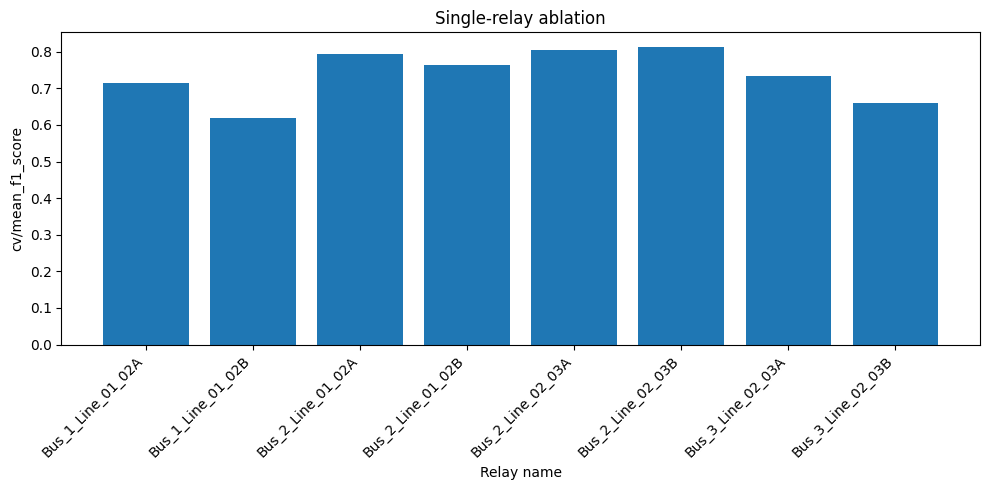

In [311]:
plot_single_relay(single_relay_summary, METRIC_COL)

## 12. Plot relay_subset

In [312]:
def plot_relay_subset(summary_df: pd.DataFrame, metric_col_name: str):
    if summary_df.empty:
        print("No relay_subset runs found.")
        return

    tmp = summary_df.copy()

    x = tmp["relay_subset_name"].astype(str).tolist()
    y = tmp["mean"].astype(float)
    yerr = tmp["std"].fillna(0).astype(float)

    plt.figure(figsize=(12, 6))
    plt.bar(range(len(tmp)), y, yerr=yerr)
    plt.xticks(range(len(tmp)), x, rotation=45, ha="right")
    plt.xlabel("Relay subset")
    plt.ylabel(metric_col_name)
    plt.title("Relay-subset ablation")
    plt.tight_layout()
    plt.show()

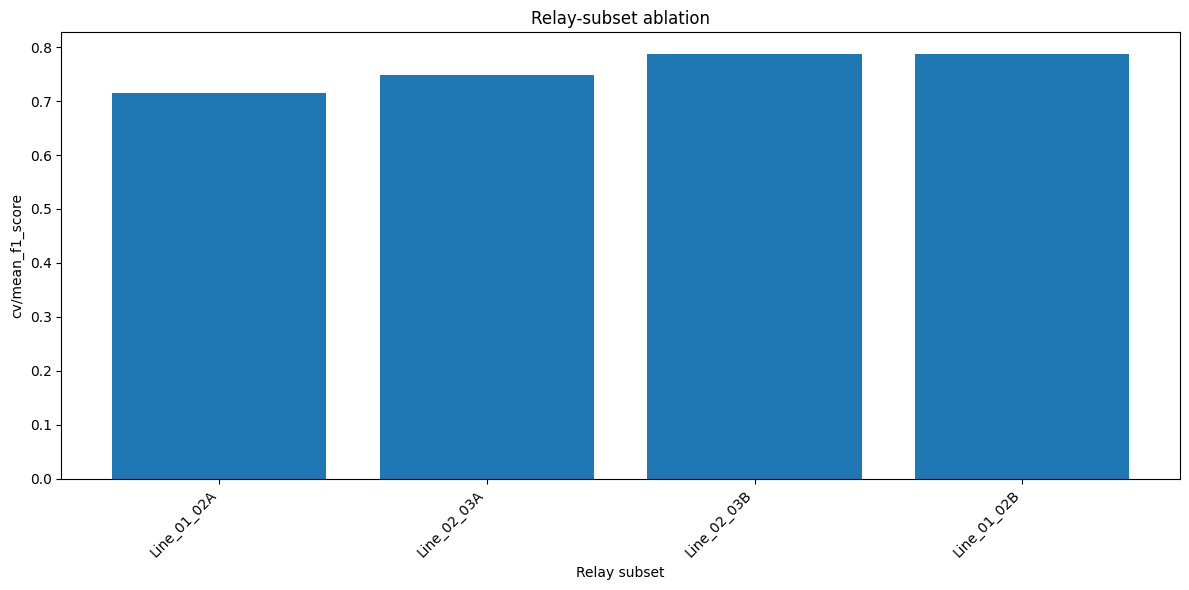

In [313]:
plot_relay_subset(relay_subset_summary, METRIC_COL)

## 13. Create a compact paper-ready table

In [314]:
def build_compact_ablation_table(
    df: pd.DataFrame,
    metric_col: str,
) -> pd.DataFrame:
    rows = []

    if "ablation/mode" not in df.columns:
        raise ValueError("Column 'ablation/mode' not found.")

    for ablation_mode, subdf in df.groupby("ablation/mode"):
        vals = subdf[metric_col].dropna().astype(float)
        print(f"Ablation mode: {ablation_mode}, n={len(vals)}, mean={vals.mean():.4f}")

        if len(vals) == 0:
            continue

        rows.append(
            {
                "ablation_mode": ablation_mode,
                "n_runs": len(vals),
                "mean": vals.mean(),
                "std": vals.std(ddof=1) if len(vals) > 1 else np.nan,
                "best": vals.min(),  # for MAE / RMSE; adjust if higher-is-better
                "worst": vals.max(),
            }
        )

    table = pd.DataFrame(rows).sort_values("mean").reset_index(drop=True)
    return table

In [315]:
df_sel[df_sel["ablation/mode"] == "single_relay"]

,name,task/type,model/name,cv/n_splits,hgb/max_iter,features/flat,hgb/max_depth,window/step_s,cv/random_state,window/length_s,...,cv/oof/fault_only_fault_start/f1_by_fault_line/size,cv/oof/fault_start_only/f1_by_fault_line/_latest_artifact_path,cv/oof/fault_start_only/f1_by_fault_line/_type,cv/oof/fault_start_only/f1_by_fault_line/artifact_path,cv/oof/fault_start_only/f1_by_fault_line/log_mode,cv/oof/fault_start_only/f1_by_fault_line/ncols,cv/oof/fault_start_only/f1_by_fault_line/nrows,cv/oof/fault_start_only/f1_by_fault_line/path,cv/oof/fault_start_only/f1_by_fault_line/sha256,cv/oof/fault_start_only/f1_by_fault_line/size
4,eager-frog-689,multiclass,hist_gradient_boosting_classifier,5.0,100.0,768.0,NaN,0.005,42.0,0.02,...,438.0,wandb-client-artifact://lglx0pqgdemx05x4zjixjg...,table-file,wandb-client-artifact://hyt3heblp3xwnxrt6vf2o3...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,f7e73ebab80862a608fe1066badfc533b8af89a06bc0c9...,414.0
5,clear-valley-690,multiclass,hist_gradient_boosting_classifier,5.0,100.0,768.0,NaN,0.005,42.0,0.02,...,436.0,wandb-client-artifact://o20fzqqahqkkh8ujsi4nka...,table-file,wandb-client-artifact://3jpyw5gwa9k3q2a419ayzl...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,aaaea3cb34ea2be7b06b6c293cb9365eb8e104401099f1...,412.0
6,vibrant-smoke-691,multiclass,hist_gradient_boosting_classifier,5.0,100.0,768.0,NaN,0.005,42.0,0.02,...,437.0,wandb-client-artifact://tgwbm6ppp742maheujm444...,table-file,wandb-client-artifact://6zg81vns53uioh064g47rj...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,59deeb467268df9278b68e572e667ebdf5ee84cf98bc4e...,413.0
7,worthy-durian-692,multiclass,hist_gradient_boosting_classifier,5.0,100.0,768.0,NaN,0.005,42.0,0.02,...,435.0,wandb-client-artifact://ch95yp426t9cpdwyepd3gz...,table-file,wandb-client-artifact://vjvadlqa2duqw4y59hettc...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,dccdb24443de72a4dcb178e31e7296873720b74ec6a288...,411.0
8,effortless-water-693,multiclass,hist_gradient_boosting_classifier,5.0,100.0,768.0,NaN,0.005,42.0,0.02,...,437.0,wandb-client-artifact://40eroxg2poo78dy69c4kv5...,table-file,wandb-client-artifact://htkkyxubfmh4ifvcywsplv...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,a70bebab8705cc19b628551c0c218765986fd60fba9ae7...,413.0
9,young-valley-694,multiclass,hist_gradient_boosting_classifier,5.0,100.0,768.0,NaN,0.005,42.0,0.02,...,435.0,wandb-client-artifact://w67583edhmb71vjjbvvlh9...,table-file,wandb-client-artifact://3905mcyo7p7txmmtla7vc0...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,21462e1d20921bf171f763906f08435a6f438f43bf4937...,411.0
10,dazzling-voice-696,multiclass,hist_gradient_boosting_classifier,5.0,100.0,768.0,NaN,0.005,42.0,0.02,...,437.0,wandb-client-artifact://p1jg4e30zaugmevusmhqd5...,table-file,wandb-client-artifact://4z321nomz917qqdol5sl1g...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,b4721958485fd5fbea336330629edca299466b28876af7...,413.0
11,lively-cosmos-697,multiclass,hist_gradient_boosting_classifier,5.0,100.0,768.0,NaN,0.005,42.0,0.02,...,436.0,wandb-client-artifact://n8sf6251oacco32t3tixtc...,table-file,wandb-client-artifact://t1cmx2udxfu86knui46rzi...,IMMUTABLE,5.0,4.0,media/table/cv/oof/fault_start_only/f1_by_faul...,53cc5b5c091c78baaa7dc0e29b6693c9476f8a9d810519...,412.0


In [316]:
compact_table = build_compact_ablation_table(df_sel, METRIC_COL)
compact_table

Ablation mode: relay_subset, n=4, mean=0.7599
Ablation mode: single_relay, n=8, mean=0.7375


,ablation_mode,n_runs,mean,std,best,worst
0,single_relay,8,0.737482,0.070201,0.618882,0.812275
1,relay_subset,4,0.759919,0.034735,0.715851,0.788046


In [317]:
def dataframe_to_latex(df: pd.DataFrame, float_format="%.3f") -> str:
    return df.to_latex(
        index=False,
        escape=False,
        float_format=float_format,
        na_rep="--",
    )

In [318]:
latex_compact = dataframe_to_latex(compact_table)
print(latex_compact)

\begin{tabular}{lrrrrr}
\toprule
ablation_mode & n_runs & mean & std & best & worst \\
\midrule
single_relay & 8 & 0.737 & 0.070 & 0.619 & 0.812 \\
relay_subset & 4 & 0.760 & 0.035 & 0.716 & 0.788 \\
\bottomrule
\end{tabular}



In [319]:
latex_single_relay = dataframe_to_latex(single_relay_summary)
print(latex_single_relay)

\begin{tabular}{rlrrrrr}
\toprule
relay_index & relay_name & count & mean & std & min & max \\
\midrule
0.000 & Bus_1_Line_01_02A & 1 & 0.713 & -- & 0.713 & 0.713 \\
1.000 & Bus_1_Line_01_02B & 1 & 0.619 & -- & 0.619 & 0.619 \\
2.000 & Bus_2_Line_01_02A & 1 & 0.793 & -- & 0.793 & 0.793 \\
3.000 & Bus_2_Line_01_02B & 1 & 0.764 & -- & 0.764 & 0.764 \\
4.000 & Bus_2_Line_02_03A & 1 & 0.805 & -- & 0.805 & 0.805 \\
5.000 & Bus_2_Line_02_03B & 1 & 0.812 & -- & 0.812 & 0.812 \\
6.000 & Bus_3_Line_02_03A & 1 & 0.734 & -- & 0.734 & 0.734 \\
7.000 & Bus_3_Line_02_03B & 1 & 0.660 & -- & 0.660 & 0.660 \\
\bottomrule
\end{tabular}



In [320]:
latex_relay_subset = dataframe_to_latex(relay_subset_summary)
print(latex_relay_subset)

\begin{tabular}{lllrrrrr}
\toprule
relay_subset_key & relay_subset_name & relay_subset & count & mean & std & min & max \\
\midrule
(0, 2) & Line_01_02A & [0, 2] & 1 & 0.716 & -- & 0.716 & 0.716 \\
(4, 6) & Line_02_03A & [4, 6] & 1 & 0.748 & -- & 0.748 & 0.748 \\
(5, 7) & Line_02_03B & [5, 7] & 1 & 0.787 & -- & 0.787 & 0.787 \\
(1, 3) & Line_01_02B & [1, 3] & 1 & 0.788 & -- & 0.788 & 0.788 \\
\bottomrule
\end{tabular}



In [321]:
output_dir = Path("ablation_outputs")
output_dir.mkdir(exist_ok=True)

print(f"USed model: {MODEL_NAME}")
print(f"Used window length (s): {WINDOW_LENGTH_S}")
print(f"Target label: {TARGET_LABEL}")

compact_table.to_csv(output_dir / f"compact_ablation_table_{MODEL_NAME}_w{WINDOW_LENGTH_S}s_{TARGET_LABEL}.csv", index=False)
single_relay_summary.to_csv(output_dir / f"single_relay_summary_{MODEL_NAME}_w{WINDOW_LENGTH_S}s_{TARGET_LABEL}.csv", index=False)
relay_subset_summary.to_csv(output_dir / f"relay_subset_summary_{MODEL_NAME}_w{WINDOW_LENGTH_S}s_{TARGET_LABEL}.csv", index=False)

(output_dir / f"compact_ablation_table_{MODEL_NAME}_w{WINDOW_LENGTH_S}s_{TARGET_LABEL}.tex").write_text(latex_compact)
(output_dir / f"single_relay_summary_{MODEL_NAME}_w{WINDOW_LENGTH_S}s_{TARGET_LABEL}.tex").write_text(latex_single_relay)
(output_dir / f"relay_subset_summary_{MODEL_NAME}_w{WINDOW_LENGTH_S}s_{TARGET_LABEL}.tex").write_text(latex_relay_subset)

print(f"Saved to: {output_dir.resolve()}")

USed model: hist_gradient_boosting_classifier
Used window length (s): 0.02
Target label: event_type
Saved to: C:\Users\user\Repositories\fault-classification-localization\notebooks\ablation_outputs


## 15. One useful pivot for interpretation

This is often the most readable notebook table.

In [322]:
pivot_cols = ["name", "ablation/mode", METRIC_COL]

if "ablation/relay_index" in df_sel.columns:
    pivot_cols.append("ablation/relay_index")

if "ablation/relay_indices" in df_sel.columns:
    pivot_cols.append("ablation/relay_indices")

df_sel[pivot_cols].sort_values(["ablation/mode", METRIC_COL]).head(50)

,name,ablation/mode,cv/mean_f1_score,ablation/relay_index,ablation/relay_indices
0,skilled-waterfall-678,relay_subset,0.715851,0.0,"[0, 2]"
2,logical-violet-680,relay_subset,0.748405,0.0,"[4, 6]"
3,hardy-frog-681,relay_subset,0.787376,0.0,"[5, 7]"
1,elated-waterfall-679,relay_subset,0.788046,0.0,"[1, 3]"
5,clear-valley-690,single_relay,0.618882,1.0,"[0, 1]"
11,lively-cosmos-697,single_relay,0.660097,7.0,"[0, 1]"
4,eager-frog-689,single_relay,0.713366,0.0,"[0, 1]"
10,dazzling-voice-696,single_relay,0.734118,6.0,"[0, 1]"
7,worthy-durian-692,single_relay,0.763633,3.0,"[0, 1]"
6,vibrant-smoke-691,single_relay,0.792960,2.0,"[0, 1]"


## 16. Minimal interpretation block for the notebook

Once the tables are generated, this is the pattern I would use:

In [323]:
print("Overall summary by ablation type:")
display(compact_table)

print("\nBest single-relay settings:")
display(single_relay_summary.head())

print("\nBest relay-subset settings:")
display(relay_subset_summary.head())

Overall summary by ablation type:


,ablation_mode,n_runs,mean,std,best,worst
0,single_relay,8,0.737482,0.070201,0.618882,0.812275
1,relay_subset,4,0.759919,0.034735,0.715851,0.788046



Best single-relay settings:


,relay_index,relay_name,count,mean,std,min,max
0,0.0,Bus_1_Line_01_02A,1,0.713366,NaN,0.713366,0.713366
1,1.0,Bus_1_Line_01_02B,1,0.618882,NaN,0.618882,0.618882
2,2.0,Bus_2_Line_01_02A,1,0.792960,NaN,0.792960,0.792960
3,3.0,Bus_2_Line_01_02B,1,0.763633,NaN,0.763633,0.763633
4,4.0,Bus_2_Line_02_03A,1,0.804523,NaN,0.804523,0.804523



Best relay-subset settings:


,relay_subset_key,relay_subset_name,relay_subset,count,mean,std,min,max
0,"(0, 2)",Line_01_02A,"[0, 2]",1,0.715851,NaN,0.715851,0.715851
2,"(4, 6)",Line_02_03A,"[4, 6]",1,0.748405,NaN,0.748405,0.748405
3,"(5, 7)",Line_02_03B,"[5, 7]",1,0.787376,NaN,0.787376,0.787376
1,"(1, 3)",Line_01_02B,"[1, 3]",1,0.788046,NaN,0.788046,0.788046
